BUILDING A BASIC CHATBOT WITH LANGGRAPH (GRAPH API)

In [1]:
from dotenv import load_dotenv
import os

load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [2]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="openai/gpt-oss-20b")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.5', 'langchain': '1.4.3'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000021065F97B60>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000021066134980>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'))

1) Simple Chatbot

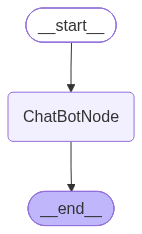

In [3]:
from typing_extensions import TypedDict, Annotated
from langgraph.graph import START, END, StateGraph
from langgraph.graph.message import add_messages
from IPython.display import display, Image

class State(TypedDict):
    messages : Annotated[list,add_messages]

def chatbot(state : State):
    return {"messages" : [llm.invoke(state["messages"])]}

graph_builder = StateGraph(State)
graph_builder.add_node("ChatBotNode",chatbot)
graph_builder.add_edge(START,"ChatBotNode")
graph_builder.add_edge("ChatBotNode",END)
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [4]:
response = graph.invoke({"messages" : "Hi! How are you? I hope you are doing well."})
response["messages"]

[HumanMessage(content='Hi! How are you? I hope you are doing well.', additional_kwargs={}, response_metadata={}, id='cdad27b3-98a5-458d-9a8b-99114e455048'),
 AIMessage(content='Hello! I’m just a virtual assistant, so I don’t have feelings, but I’m here and ready to help. What’s on your mind today?', additional_kwargs={'reasoning_content': 'We have a conversation: user says "Hi! How are you? I hope you are doing well." We need to respond. The user is greeting. The instruction: "You are ChatGPT, a large language model trained by OpenAI." There\'s no special instructions. We should respond politely. Possibly ask user what they need help with. Let\'s respond warmly.\n\nWe should also consider the policy: no disallowed content. It\'s fine.\n\nWe can respond with something like: "Hello! I\'m an AI, so I don\'t have feelings, but thanks for asking. How can I help you today?" That is typical.'}, response_metadata={'token_usage': {'completion_tokens': 165, 'prompt_tokens': 84, 'total_tokens': 2

2. Simple Chatbot with Tools

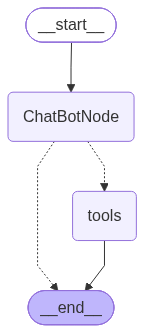

In [5]:
from typing_extensions import TypedDict, Annotated
from langgraph.graph import START, END, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_tavily import TavilySearch
from IPython.display import display, Image

class State(TypedDict):
    messages : Annotated[list,add_messages]

def tool1(city : str) -> str:
    """Gives the current weather of the given city"""
    return f"The weather in {city} is clear and pleasant."

tool2 = TavilySearch(max_results=2)

tool = [tool1,tool2]

llm_with_tools = llm.bind_tools(tool)

def chatbot(state : State):
    return {"messages" : [llm_with_tools.invoke(state["messages"])]}

graph_builder = StateGraph(State)
graph_builder.add_node("ChatBotNode",chatbot)
graph_builder.add_node("tools",ToolNode(tool))
graph_builder.add_edge(START,"ChatBotNode")
graph_builder.add_conditional_edges("ChatBotNode",tools_condition)
graph_builder.add_edge("tools",END)
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [6]:
response = graph.invoke({"messages" : "What is the latest AI news?"})
response["messages"]

[HumanMessage(content='What is the latest AI news?', additional_kwargs={}, response_metadata={}, id='e30940ee-4e1c-4255-8ffb-77bffc299257'),
 AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to answer: "What is the latest AI news?" We should browse up-to-date info. Use tavily_search.', 'tool_calls': [{'id': 'fc_db1ccda0-7fd0-4938-95d4-fae3c0963db0', 'function': {'arguments': '{"query":"latest AI news","search_depth":"advanced","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 63, 'prompt_tokens': 344, 'total_tokens': 407, 'completion_time': 0.072081731, 'completion_tokens_details': {'reasoning_tokens': 27}, 'prompt_time': 0.021883505, 'prompt_tokens_details': None, 'queue_time': 0.209855471, 'total_time': 0.093965236}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_a8c584dda7', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq

In [7]:
response = graph.invoke({"messages" : "What is the weather in Mumbai and then give me the latest AI news?"})
response["messages"]

[HumanMessage(content='What is the weather in Mumbai and then give me the latest AI news?', additional_kwargs={}, response_metadata={}, id='b848f68c-a144-407d-81e6-7407b99b2160'),
 AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to use the tool to get current weather of Mumbai. Then we need latest AI news. For news, we can use tavily_search with query "latest AI news" and maybe filter recent. Probably include time_range "day" or "week". Provide answer.', 'tool_calls': [{'id': 'fc_e2681f5b-8236-46b6-88cc-80d969ad0df7', 'function': {'arguments': '{"query":"latest AI news","search_depth":"basic","time_range":"day","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 110, 'prompt_tokens': 352, 'total_tokens': 462, 'completion_time': 0.112292657, 'completion_tokens_details': {'reasoning_tokens': 56}, 'prompt_time': 0.017280191, 'prompt_tokens_details': None, 'queue_time': 0.212078074, 'total_time': 

3. ReACT Agent Architechture

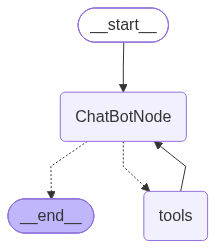

In [8]:
from typing_extensions import TypedDict, Annotated
from langgraph.graph import START, END, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_tavily import TavilySearch
from IPython.display import display, Image

class State(TypedDict):
    messages : Annotated[list,add_messages]

def tool1(city : str) -> str:
    """Gives the current weather of the given city"""
    return f"The weather in {city} is clear and pleasant."

tool2 = TavilySearch(max_results=2)

tool = [tool1,tool2]

llm_with_tools = llm.bind_tools(tool)

def chatbot(state : State):
    return {"messages" : [llm_with_tools.invoke(state["messages"])]}

graph_builder = StateGraph(State)
graph_builder.add_node("ChatBotNode",chatbot)
graph_builder.add_node("tools",ToolNode(tool))
graph_builder.add_edge(START,"ChatBotNode")
graph_builder.add_conditional_edges("ChatBotNode",tools_condition)
graph_builder.add_edge("tools","ChatBotNode")
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [9]:
response = graph.invoke({"messages" : "What is the weather in Mumbai and then give me the latest AI news?"})
response["messages"]

[HumanMessage(content='What is the weather in Mumbai and then give me the latest AI news?', additional_kwargs={}, response_metadata={}, id='97a7586d-1059-4dd5-aef0-c476de33542c'),
 AIMessage(content='', additional_kwargs={'reasoning_content': 'Need to get current weather for Mumbai. Use tool1. Then need latest AI news. Use tavily_search. Probably search for "latest AI news" within last day. We\'ll get results.', 'tool_calls': [{'id': 'fc_77e638aa-a3fc-407a-a74d-658c70c674f0', 'function': {'arguments': '{"city":"Mumbai"}', 'name': 'tool1'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 63, 'prompt_tokens': 352, 'total_tokens': 415, 'completion_time': 0.065007532, 'completion_tokens_details': {'reasoning_tokens': 40}, 'prompt_time': 0.034775249, 'prompt_tokens_details': None, 'queue_time': 0.211203886, 'total_time': 0.099782781}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_e23fc997ca', 'service_tier': 'on_demand', 'finish_reason': 'tool_

4. ReACT Agent with Memory

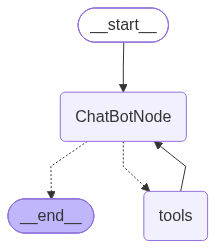

In [10]:
from typing_extensions import TypedDict, Annotated
from langgraph.graph import START, END, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import InMemorySaver
from langchain_tavily import TavilySearch
from IPython.display import display, Image

class State(TypedDict):
    messages : Annotated[list,add_messages]

def tool1(city : str) -> str:
    """Gives the current weather of the given city"""
    return f"The weather in {city} is clear and pleasant."

tool2 = TavilySearch(max_results=2)

tool = [tool1,tool2]

llm_with_tools = llm.bind_tools(tool)

def chatbot(state : State):
    return {"messages" : [llm_with_tools.invoke(state["messages"])]}

graph_builder = StateGraph(State)
graph_builder.add_node("ChatBotNode",chatbot)
graph_builder.add_node("tools",ToolNode(tool))
graph_builder.add_edge(START,"ChatBotNode")
graph_builder.add_conditional_edges("ChatBotNode",tools_condition)
graph_builder.add_edge("tools","ChatBotNode")
graph = graph_builder.compile(checkpointer=InMemorySaver())
display(Image(graph.get_graph().draw_mermaid_png()))

In [11]:
config = {"configurable" : {"thread_id" : "thread"}}

In [12]:
response = graph.invoke({"messages" : "Hello! My name is Nupur."},config)
response["messages"]

[HumanMessage(content='Hello! My name is Nupur.', additional_kwargs={}, response_metadata={}, id='52cb9dcf-5802-45a4-a677-0cf21e483ab0'),
 AIMessage(content='Hello Nupur! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'We greet Nupur. No tool usage needed.'}, response_metadata={'token_usage': {'completion_tokens': 35, 'prompt_tokens': 346, 'total_tokens': 381, 'completion_time': 0.036005246, 'completion_tokens_details': {'reasoning_tokens': 12}, 'prompt_time': 0.020899266, 'prompt_tokens_details': None, 'queue_time': 0.340328079, 'total_time': 0.056904512}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_34cb00738d', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0fbfa-94e1-75b0-b33f-31ae57d5d84e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 346, 'output_tokens': 35, 'total_tokens': 381, 'output_token_details': {'reasoning': 12}})]

In [13]:
response = graph.invoke({"messages" : "How are you?"},config)
response["messages"]

[HumanMessage(content='Hello! My name is Nupur.', additional_kwargs={}, response_metadata={}, id='52cb9dcf-5802-45a4-a677-0cf21e483ab0'),
 AIMessage(content='Hello Nupur! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'We greet Nupur. No tool usage needed.'}, response_metadata={'token_usage': {'completion_tokens': 35, 'prompt_tokens': 346, 'total_tokens': 381, 'completion_time': 0.036005246, 'completion_tokens_details': {'reasoning_tokens': 12}, 'prompt_time': 0.020899266, 'prompt_tokens_details': None, 'queue_time': 0.340328079, 'total_time': 0.056904512}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_34cb00738d', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0fbfa-94e1-75b0-b33f-31ae57d5d84e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 346, 'output_tokens': 35, 'total_tokens': 381, 'output_token_details': {'reasoning': 12}}),
 HumanMessage(content='H

In [14]:
response = graph.invoke({"messages" : "Do you know my name?"},config)
response["messages"]

[HumanMessage(content='Hello! My name is Nupur.', additional_kwargs={}, response_metadata={}, id='52cb9dcf-5802-45a4-a677-0cf21e483ab0'),
 AIMessage(content='Hello Nupur! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'We greet Nupur. No tool usage needed.'}, response_metadata={'token_usage': {'completion_tokens': 35, 'prompt_tokens': 346, 'total_tokens': 381, 'completion_time': 0.036005246, 'completion_tokens_details': {'reasoning_tokens': 12}, 'prompt_time': 0.020899266, 'prompt_tokens_details': None, 'queue_time': 0.340328079, 'total_time': 0.056904512}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_34cb00738d', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0fbfa-94e1-75b0-b33f-31ae57d5d84e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 346, 'output_tokens': 35, 'total_tokens': 381, 'output_token_details': {'reasoning': 12}}),
 HumanMessage(content='H

STREAMING

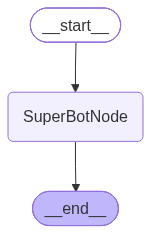

In [15]:
from typing_extensions import TypedDict, Annotated
from langgraph.graph import START, END, StateGraph
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver
from IPython.display import display, Image

class State(TypedDict):
    messages : Annotated[list,add_messages]

def chatbot(state : State):
    return {"messages" : [llm.invoke(state["messages"])]}

graph_builder = StateGraph(State)
graph_builder.add_node("SuperBotNode",chatbot)
graph_builder.add_edge(START,"SuperBotNode")
graph_builder.add_edge("SuperBotNode",END)
graph = graph_builder.compile(checkpointer=InMemorySaver())
display(Image(graph.get_graph().draw_mermaid_png()))

.stream() and .astream() are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state:- 

1. values : This streams the full state of the graph after each node is called.

2. updates : This streams updates to the state of the graph after each node is called.

In [16]:
config = {"configurable" : {"thread_id" : "1"}}

for chunk in graph.stream({"messages" : "Hello! My name is Nupur."},config,stream_mode="values"):
    print(chunk)

for chunk in graph.stream({"messages" : "How are you? Do you know my name?"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hello! My name is Nupur.', additional_kwargs={}, response_metadata={}, id='893d16db-c4f2-48e4-97a0-a5bb521a3e9c')]}
{'messages': [HumanMessage(content='Hello! My name is Nupur.', additional_kwargs={}, response_metadata={}, id='893d16db-c4f2-48e4-97a0-a5bb521a3e9c'), AIMessage(content='Hi Nupur! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'We need to respond with a friendly greeting. We should ask if she wants help with something.'}, response_metadata={'token_usage': {'completion_tokens': 43, 'prompt_tokens': 80, 'total_tokens': 123, 'completion_time': 0.048146444, 'completion_tokens_details': {'reasoning_tokens': 20}, 'prompt_time': 0.036860481, 'prompt_tokens_details': None, 'queue_time': 0.349257082, 'total_time': 0.085006925}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_99996fee8e', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0fbfa-a13

In [17]:
config = {"configurable" : {"thread_id" : "2"}}

for chunk in graph.stream({"messages" : "Hello! My name is Nupur."},config,stream_mode="updates"):
    print(chunk)

for chunk in graph.stream({"messages" : "How are you? Do you know my name?"},config,stream_mode="updates"):
    print(chunk)

{'SuperBotNode': {'messages': [AIMessage(content='Hello, Nupur! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'We have a conversation. The user says "Hello! My name is Nupur." We need to respond. We have to follow the system instructions: we are a large language model. There\'s no special instruction beyond normal. We should respond politely, ask how we can help, maybe ask what the user wants. There\'s no conflict with policy. We can just greet them.'}, response_metadata={'token_usage': {'completion_tokens': 100, 'prompt_tokens': 80, 'total_tokens': 180, 'completion_time': 0.102301878, 'completion_tokens_details': {'reasoning_tokens': 76}, 'prompt_time': 0.004113014, 'prompt_tokens_details': None, 'queue_time': 0.209494032, 'total_time': 0.106414892}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_a12402de73', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0fbfa-a5fb-7131-a8f4-1e2e

In [18]:
config = {"configurable" : {"thread_id" : "3"}}

async for event in graph.astream_events({"messages" : "Hello! My name is Nupur."},config):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'Hello! My name is Nupur.'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '01a0fbfa-a9f1-7f30-b169-c8c283ff61bc', 'metadata': {'thread_id': '3', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hello! My name is Nupur.', additional_kwargs={}, response_metadata={}, id='6f038a3c-b2a6-4a27-94c2-875f114ee7f1')]}}, 'name': 'SuperBotNode', 'tags': ['graph:step:1'], 'run_id': '01a0fbfa-a9f8-7a83-99cb-efa27b816e0b', 'metadata': {'thread_id': '3', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBotNode', 'langgraph_triggers': ('branch:to:SuperBotNode',), 'langgraph_path': ('__pregel_pull', 'SuperBotNode'), 'langgraph_checkpoint_ns': 'SuperBotNode:094f3cdb-9e20-2be8-8cae-9967f2591b1d'}, 'parent_ids': ['01a0fbfa-a9f1-7f30-b169-c8c283ff61bc']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessage(content='H